In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    'Student_ID': range(1, 51),
    'Math_Score': np.random.randint(40, 100, 50),
    'Science_Score': np.random.randint(35, 100, 50),
    'English_Score': np.random.randint(45, 100, 50),
    'Attendance': np.random.randint(60, 100, 50),
    'Study_Hours': np.random.randint(1, 10, 50)
})

In [ ]:
# Add missing values
df.loc[5, 'Math_Score'] = np.nan
df.loc[10, 'Science_Score'] = np.nan

In [ ]:
# Add inconsistent values
df.loc[15, 'Attendance'] = 150   # invalid (>100)
df.loc[20, 'Study_Hours'] = -3   # invalid (<0)

In [ ]:
print("Initial Data:\n", df.head())


Initial Data:
    Student_ID  Math_Score  Science_Score  English_Score  Attendance  \
0           1        78.0           85.0             79          89   
1           2        91.0           41.0             77          96   
2           3        68.0           55.0             49          82   
3           4        54.0           73.0             86          98   
4           5        82.0           52.0             83          74   

   Study_Hours  
0            1  
1            1  
2            3  
3            2  
4            5  


In [ ]:
# Step 2: Check missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Student_ID       0
Math_Score       1
Science_Score    1
English_Score    0
Attendance       0
Study_Hours      0
dtype: int64


In [ ]:
# Correct way (no warning)
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].mean())
df['Science_Score'] = df['Science_Score'].fillna(df['Science_Score'].mean())


In [ ]:
df['Attendance'] = np.where(df['Attendance'] > 100, 100, df['Attendance'])
df['Attendance'] = np.where(df['Attendance'] < 0, 0, df['Attendance'])


In [ ]:
df['Study_Hours'] = np.where(df['Study_Hours'] < 0,
                            df['Study_Hours'].median(),
                            df['Study_Hours'])

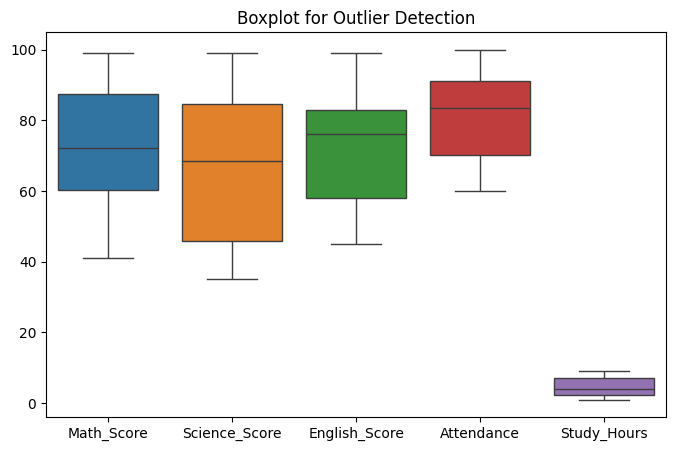

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Math_Score','Science_Score','English_Score','Attendance','Study_Hours']])
plt.title("Boxplot for Outlier Detection")
plt.show()

In [ ]:
for col in ['Math_Score','Science_Score','English_Score','Attendance','Study_Hours']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

In [ ]:
df['Math_Score'] = (df['Math_Score'] - df['Math_Score'].min()) / (df['Math_Score'].max() - df['Math_Score'].min())


In [ ]:
df['Study_Hours_Log'] = np.log(df['Study_Hours'] + 1)


In [ ]:
print("\nCleaned Data:\n", df.head())
print("\nSummary:\n", df.describe())


Cleaned Data:
    Student_ID  Math_Score  Science_Score  English_Score  Attendance  \
0           1    0.637931           85.0           79.0        89.0   
1           2    0.862069           41.0           77.0        96.0   
2           3    0.465517           55.0           49.0        82.0   
3           4    0.224138           73.0           86.0        98.0   
4           5    0.706897           52.0           83.0        74.0   

   Study_Hours  Study_Hours_Log  
0          1.0         0.693147  
1          1.0         0.693147  
2          3.0         1.386294  
3          2.0         1.098612  
4          5.0         1.791759  

Summary:
        Student_ID  Math_Score  Science_Score  English_Score  Attendance  \
count    50.00000   50.000000      50.000000       50.00000   50.000000   
mean     25.50000    0.540816      66.102041       71.98000   81.120000   
std      14.57738    0.298847      20.925763       15.74217   12.712905   
min       1.00000    0.000000      35.0000